In [49]:
import pandas as pd
from seismostats import Catalog
import matplotlib.pyplot as plt
import numpy as np

from seismostats.plots import plot_cum_fmd, plot_fmd, plot_mags_in_time, plot_in_space
%config InlineBackend.figure_format ='retina'


In [50]:
delta_m = 0.01
dmc = 0.2
fmd_bin = 0.1
correction_factor = 0.2

mc_chosen_pos = 0.7
mc_train = 0.3

In [51]:

# ======== get Data =========================
# == Train==
location = 'data/training/Amatrice_CAT5_train.csv'
cat_raw = pd.read_csv(location)
cat_train = Catalog(cat_raw)
cat_train.delta_m = delta_m

# == Test==
location = 'data/testing/Amatrice_CAT5_test.csv'
cat_raw = pd.read_csv(location)
cat_test = Catalog(cat_raw)
cat_test.delta_m = delta_m

# == combined
cat_all = pd.concat([cat_train, cat_test], ignore_index=True)
cat_traintest = cat_all.copy()

Legend added to the plot.
Legend added to the plot.


/var/folders/2_/2txg_9093x37rv1ls3774xkc0000gn/T/ipykernel_853/2845353656.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


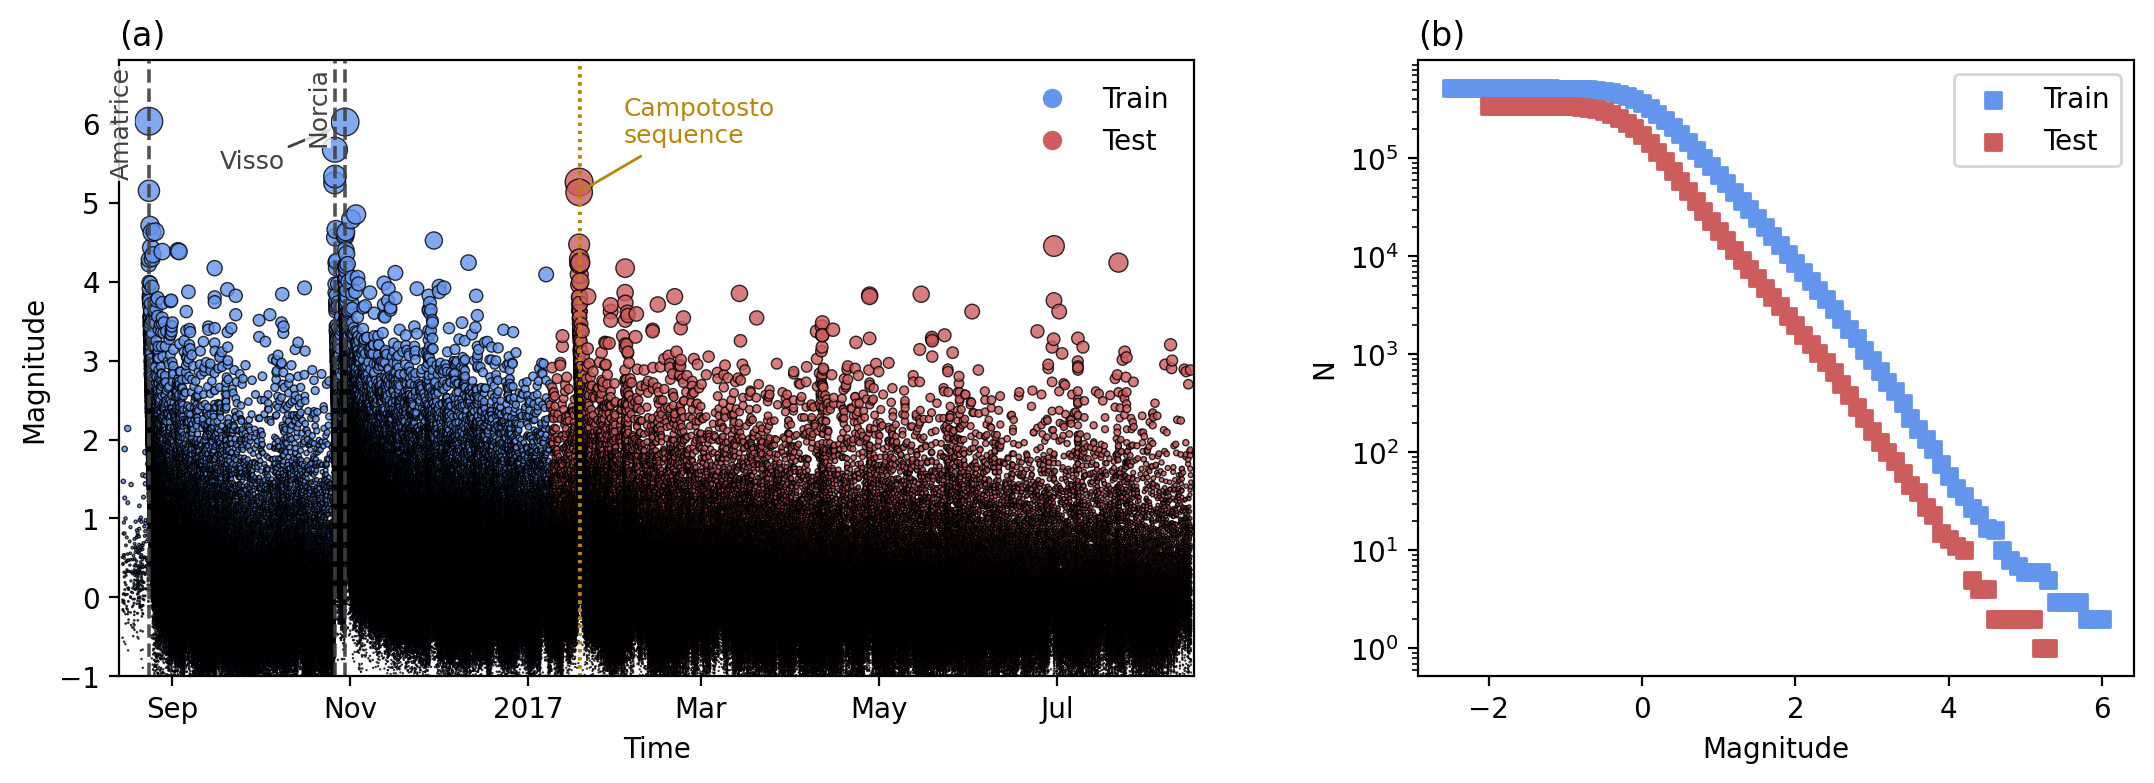

In [52]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

cat_all = cat_all.copy()
cat_all["time"] = pd.to_datetime(cat_all["time"])

mainshock_times = [
    ("Amatrice", pd.Timestamp("2016-08-24 01:36:32")),
    ("Visso", pd.Timestamp("2016-10-26 19:18:06")),
    ("Norcia", pd.Timestamp("2016-10-30 06:40:17")),
]

campotosto_times = [
    ("Campotosto 1", pd.Timestamp("2017-01-18 09:25:41")),
    ("Campotosto 2", pd.Timestamp("2017-01-18 10:14:10")),
    ("Campotosto 3", pd.Timestamp("2017-01-18 10:25:23")),
    ("Campotosto 4", pd.Timestamp("2017-01-18 13:33:37")),
]


def select_nearest_event(cat_df, target_time, max_dt="5s"):
    dt = (cat_df["time"] - target_time).abs()
    idx = dt.idxmin()
    if dt.loc[idx] > pd.Timedelta(max_dt):
        raise ValueError(f"No event found within {max_dt} of {target_time}.")
    return cat_df.loc[idx]



def select_campotosto_event(cat_df, target_time):
    window_start = target_time - pd.Timedelta(seconds=3)
    hits = cat_df[
        (cat_df["time"] > window_start)
        & (cat_df["time"] < window_start + pd.Timedelta(seconds=10))
        & (cat_df["magnitude"] > 5)
    ]
    if not hits.empty:
        return hits.sort_values("magnitude", ascending=False).iloc[0]

    fallback = cat_df.loc[(cat_df["time"] - target_time).abs().idxmin()]
    return fallback


highlight_events = []
for name, event_time in mainshock_times:
    event = select_nearest_event(cat_all, event_time).copy()
    event["event_name"] = name
    event["event_group"] = "mainshock"
    highlight_events.append(event)

for name, event_time in campotosto_times:
    event = select_campotosto_event(cat_all, event_time).copy()
    event["event_name"] = name
    event["event_group"] = "campotosto"
    highlight_events.append(event)

highlight_events = pd.DataFrame(highlight_events)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 4),
    gridspec_kw={"width_ratios": [3, 2], "wspace": 0.25}
)

# ---- Left: Magnitude vs Time (larger) ----
for df, c in zip(
    [cat_train, cat_test],
    ["cornflowerblue", "indianred"]
):
    plot_mags_in_time(
        df.time, df.magnitude,
        dot_smallest=0.1, dot_largest=100, dot_interpolation_power=5,
        color_dots=c, ax=ax1
    )

mainshock_label_y = {
    "Amatrice": 6.72,
    "Norcia": 6.72,
}
mainshock_label_xoffset = {
    "Amatrice": -14,
    "Norcia": -14,
}

for name, event_time in mainshock_times:
    ax1.axvline(
        event_time,
        color="0.25",
        linestyle="--",
        linewidth=1.3,
        alpha=0.9,
        zorder=1,
    )
    if name == "Visso":
        ax1.annotate(
            "Visso",
            xy=(event_time, 5.95),
            xytext=(-18, -8),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="-", color="0.25", linewidth=1.0),
            fontsize=9,
            color="0.25",
            ha="right",
            va="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.4),
        )
    else:
        ax1.annotate(
            name,
            xy=(event_time, mainshock_label_y[name]),
            xytext=(mainshock_label_xoffset[name], 0),
            textcoords="offset points",
            rotation=90,
            rotation_mode="anchor",
            va="top",
            ha="right",
            fontsize=9,
            color="0.25",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.4),
            clip_on=False,
        )

for _, event in highlight_events[highlight_events["event_group"] == "campotosto"].iterrows():
    ax1.axvline(
        event["time"],
        color="darkgoldenrod",
        linestyle=":",
        linewidth=1.1,
        alpha=0.9,
        zorder=1,
    )

campotosto_anchor = highlight_events[highlight_events["event_name"] == "Campotosto 2"].iloc[0]
ax1.annotate(
    "Campotosto\nsequence",
    xy=(campotosto_anchor["time"], campotosto_anchor["magnitude"]),
    xytext=(16, 16),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="-", color="darkgoldenrod", linewidth=1.0),
    fontsize=9,
    color="darkgoldenrod",
    ha="left",
    va="bottom",
)

locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax1.set(
    ylim=(-1, 6.8),
    xlim=(
        cat_all.time.min() - pd.Timedelta(days=1),
        cat_all.time.max() + pd.Timedelta(days=1)
    ),
    ylabel="Magnitude",
    xlabel="Time",
)
ax1.tick_params(axis="x", rotation=0)
ax1.legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="", markersize=7,
               markerfacecolor="cornflowerblue", markeredgecolor="none", label="Train"),
        Line2D([0], [0], marker="o", linestyle="", markersize=7,
               markerfacecolor="indianred", markeredgecolor="none", label="Test"),
    ],
    frameon=False,
    loc="upper right",
)

# ---- Right: Cumulative FMD (smaller) ----
for df, c, lbl in zip(
    [cat_train, cat_test],
    ["cornflowerblue", "indianred"],
    ["Train", "Test"]
):
    df.plot_cum_fmd(fmd_bin=0.1, color=c, label=lbl, ax=ax2)

for ax, label in zip([ax1, ax2], ["(a)", "(b)"]):
    bb = ax.get_position()
    fig.text(
        bb.x0, bb.y1 + 0.01, label,
        ha="left", va="bottom",
        fontsize=12,
    )

plt.tight_layout()
plt.show()





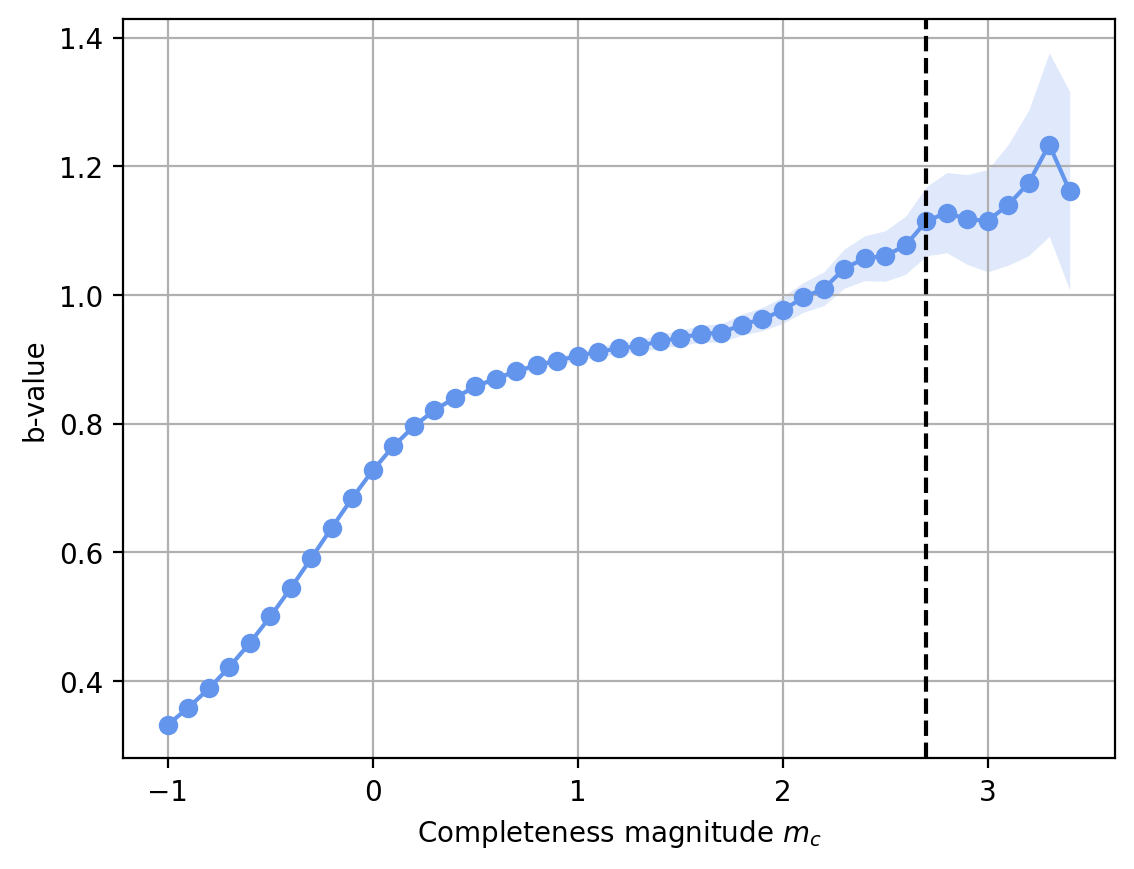

In [53]:
cat_train.plot_mc_vs_b(mcs=np.arange(-1, 3.5, 0.1), color = 'cornflowerblue')

# dotted line at mc = 2.7
plt.axvline(2.7, color='k', linestyle='--')

Text(0, 0.5, 'Northing [km]')

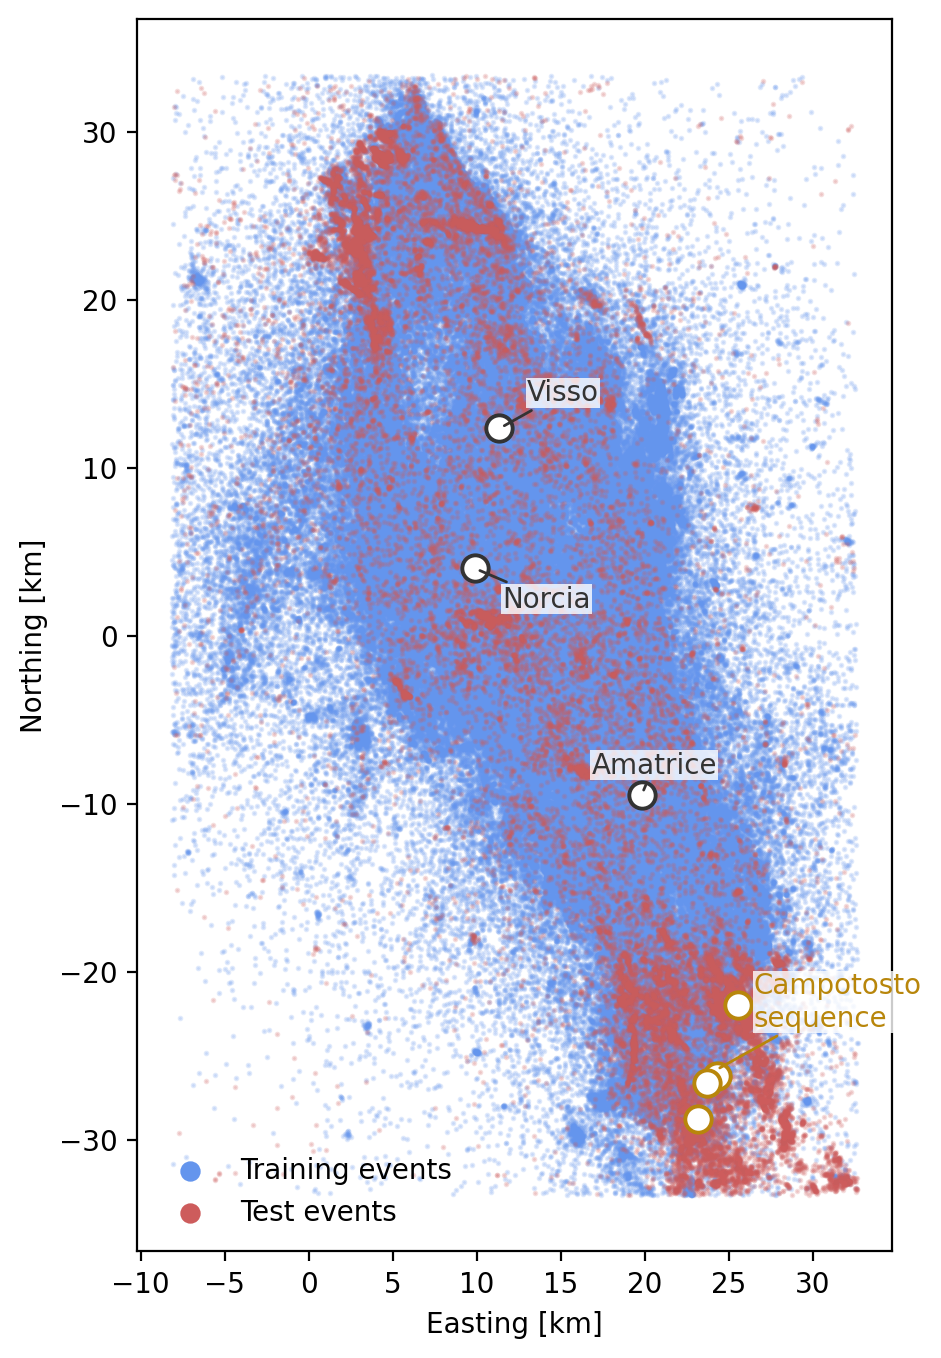

In [55]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
ax = plt.gca()

idx = cat_test['magnitude'] >= mc_train
ax.scatter(cat_train.y, cat_train.x, s=1, alpha=0.2, c='cornflowerblue')
idx = cat_test['magnitude'] >= mc_chosen_pos
ax.scatter(cat_test.y[idx], cat_test.x[idx], s=1, alpha=0.2, c='indianred')

mainshock_events = highlight_events[highlight_events['event_group'] == 'mainshock']
campotosto_events = highlight_events[highlight_events['event_group'] == 'campotosto']

ax.scatter(
    mainshock_events.y,
    mainshock_events.x,
    s=90,
    facecolors='white',
    edgecolors='0.2',
    linewidths=1.4,
    zorder=4,
)
ax.scatter(
    campotosto_events.y,
    campotosto_events.x,
    s=90,
    facecolors='white',
    edgecolors='darkgoldenrod',
    linewidths=1.4,
    zorder=4,
)

spatial_label_offsets = {
    'Amatrice': (-18, 8),
    'Visso': (10, 10),
    'Norcia': (10, -14),
}

for _, event in mainshock_events.iterrows():
    dx, dy = spatial_label_offsets[event['event_name']]
    ax.annotate(
        event['event_name'],
        xy=(event.y, event.x),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=10,
        color='0.2',
        arrowprops=dict(arrowstyle='-', color='0.2', linewidth=1.0),
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.4),
        zorder=5,
    )

campotosto_center = campotosto_events[['y', 'x']].mean()
ax.annotate(
    'Campotosto\nsequence',
    xy=(campotosto_center['y'], campotosto_center['x']),
    xytext=(14, 16),
    textcoords='offset points',
    fontsize=10,
    color='darkgoldenrod',
    arrowprops=dict(arrowstyle='-', color='darkgoldenrod', linewidth=1.0),
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.4),
    zorder=5,
)

ax.set_aspect('equal', adjustable='box')

# legend-only (big, opaque) markers
ax.scatter([], [], s=40, alpha=1, label='Training events', c='cornflowerblue')
ax.scatter([], [], s=40, alpha=1, label='Test events', c='indianred')
ax.scatter([], [], s=70, facecolors='white', edgecolors='0.2', linewidths=1.4)
ax.scatter([], [], s=70, facecolors='white', edgecolors='darkgoldenrod', linewidths=1.4)
ax.legend(frameon=False)

ax.set_xlabel('Easting [km]')
ax.set_ylabel('Northing [km]')


